In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sympy as smp
from scipy.stats import bernoulli
import pandas as pd
import math
import pylatexenc
from IPython.display import display, Math

In [ ]:
# Define omega avoiding 0 and 1 to prevent division by zero
omega = np.linspace(0.01, 0.99, 1000)

# Define lambda = 1 - omega
lmbd = 1 - omega

# Compute T
T = 1 / (np.log(omega / lmbd))


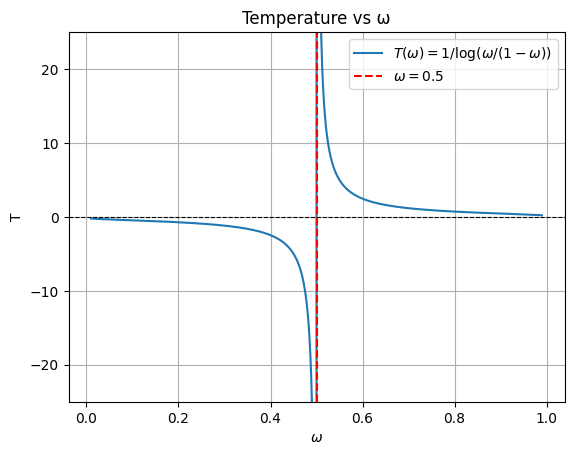

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot
plt.plot(omega, T, label=r"$T(\omega) = 1/\log(\omega/(1-\omega))$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0.5, color='red', linestyle='--', label=r'$\omega = 0.5$')
plt.xlabel(r'$\omega$')
plt.ylabel('T')
plt.title('Temperature vs ω')
plt.legend()
plt.grid(True)
plt.ylim(-25, 25)
plt.show()

plt.savefig(r"C:\Users\Pedro\Documents\temperature_vs_omega.pgf")


C:\Users\pedro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8 ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


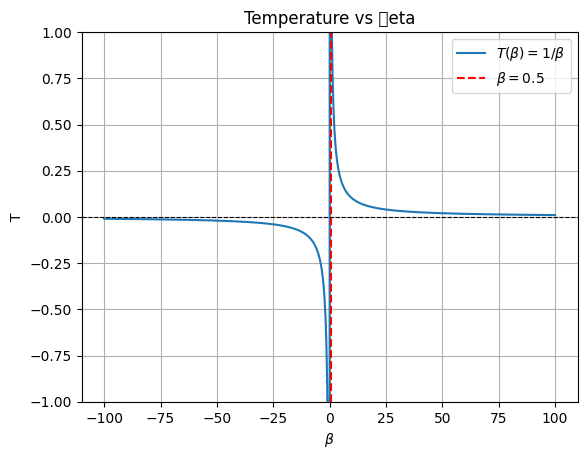

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot
beta = np.linspace(-100, 100, 1000)
T_b = 1/beta

plt.plot(beta, T_b, label=r"$T(\beta) = 1/\beta$")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')    
plt.axvline(0.5, color='red', linestyle='--', label=r'$\beta = 0.5$')
plt.xlabel(r'$\beta$')
plt.ylabel('T')
plt.title('Temperature vs \beta')
plt.legend()
plt.grid(True)
plt.ylim(-1, 1)
plt.show()

plt.savefig(r"C:\Users\Pedro\Documents\temperature_vs_beta.pgf")


In [ ]:
def probs_p(beta: float, N: int) -> np.ndarray:
    """
    Return p_i for given beta and N using stable formulas.
    Handles beta ~ 0 (a ~ 1) by taking the uniform limit.
    """
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N, dtype=float)
    else:
        # a = exp(-beta); use expm1 to avoid catastrophic cancellation
        # 1 - a     = -expm1(-beta)
        # 1 - a^N   = -expm1(-beta*N)
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)         # = 1 - a
        denom = -np.expm1(-beta * N)           # = 1 - a^N
        p = (numer_const * ai) / denom
    # Defensive normalization
    p /= p.sum()
    return p


In [ ]:
def entropy_S(beta: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(beta) = -sum p_i log p_i for an array of betas.
    """
    beta = np.atleast_1d(beta).astype(float)
    S = np.empty_like(beta, dtype=float)
    for k, b in enumerate(beta):
        p = probs_p(b, N)
        # clip to avoid log(0)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


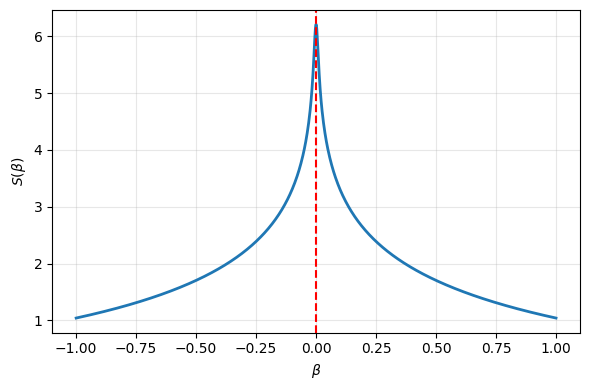

In [ ]:
# Parameters
betas = np.linspace(-1, 1, 1000)
N = 500
# Compute
S_vals = entropy_S(betas, N)

plt.figure(figsize=(6, 4))
plt.plot(betas, S_vals, linewidth=2)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$S(\beta)$")
plt.axvline(0, color='red', linestyle='--', label=r'$\beta = 0$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Pedro\Documents\S_beta_plot.pgf")

plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_7412\4176339087.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


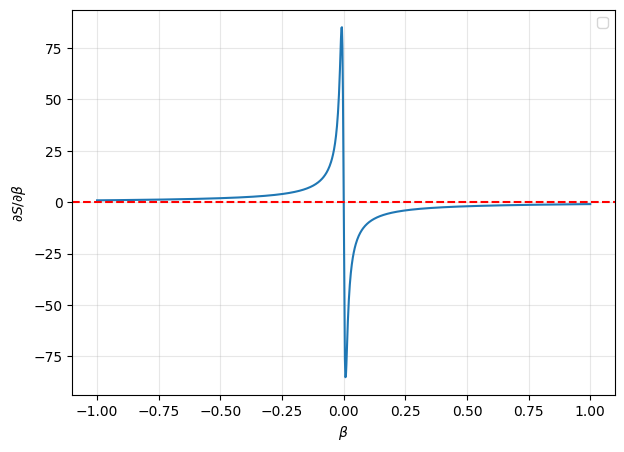

In [ ]:
dS_dbeta = np.gradient(S_vals,  betas)
plt.figure(figsize=(7,5))
plt.plot(betas, dS_dbeta)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\partial S / \partial \beta $")
plt.axhline(0, color='red', linestyle='--')

plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(r"C:\Users\Pedro\Documents\S_derivative_beta_plot.pgf")

plt.show()


In [ ]:
def probs_p_from_T(T: float, N: int) -> np.ndarray:
    """
    Return p_i for given T and N.
    Uses beta = 1/T, handles T→∞ (beta→0) as uniform distribution.
    """
    if np.isclose(T, np.inf) or np.isclose(1.0/T, 0.0, atol=1e-12):
        return np.full(N, 1.0/N)
    
    beta = 1.0 / T
    if np.isclose(beta, 0.0, atol=1e-12):
        p = np.full(N, 1.0 / N)
    else:
        i = np.arange(N, dtype=float)
        ai = np.exp(-beta * i)
        numer_const = -np.expm1(-beta)       # 1 - a
        denom = -np.expm1(-beta * N)         # 1 - a^N
        p = (numer_const * ai) / denom
    p /= p.sum()
    return p

def entropy_S_T(T: np.ndarray, N: int) -> np.ndarray:
    """
    Compute S(T) for array of T values.
    """
    T = np.atleast_1d(T).astype(float)
    S = np.empty_like(T, dtype=float)
    for k, temp in enumerate(T):
        p = probs_p_from_T(temp, N)
        p = np.clip(p, 1e-300, 1.0)
        S[k] = -np.sum(p * np.log(p))
    return S if S.size > 1 else S.item()


C:\Users\pedro\AppData\Local\Temp\ipykernel_7412\3909761569.py:14: RuntimeWarning: overflow encountered in exp
  ai = np.exp(-beta * i)
C:\Users\pedro\AppData\Local\Temp\ipykernel_7412\3909761569.py:16: RuntimeWarning: overflow encountered in expm1
  denom = -np.expm1(-beta * N)         # 1 - a^N
C:\Users\pedro\AppData\Local\Temp\ipykernel_7412\3909761569.py:17: RuntimeWarning: overflow encountered in multiply
  p = (numer_const * ai) / denom
C:\Users\pedro\AppData\Local\Temp\ipykernel_7412\3909761569.py:17: RuntimeWarning: invalid value encountered in divide
  p = (numer_const * ai) / denom


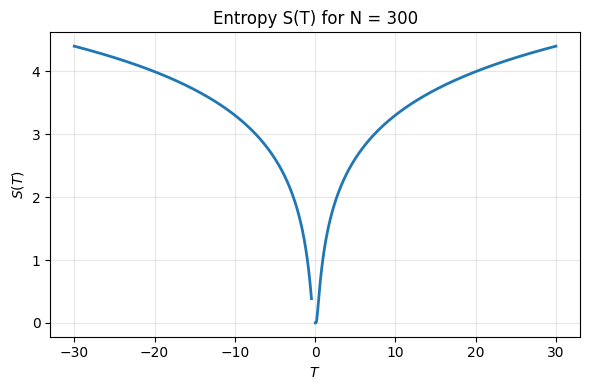

In [ ]:
N = 300
T_vals = np.linspace(-30, 30, 1000)

S_vals_T = entropy_S_T(T_vals, N)

# Plot
plt.figure(figsize=(6,4))
plt.plot(T_vals, S_vals_T, linewidth=2)
plt.xlabel(r"$T$")
plt.ylabel(r"$S(T)$")
plt.title(f"Entropy S(T) for N = {N}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("S_T_plot.png", dpi=200)
plt.show()
